<b>Ítem 1: Procesamiento de sonido</b>

Grabe un sonido interesante utilizando el micrófono integrado en su computador.
Modifique la señal con filtros que permitan resaltar alguna característica particular del
sonido.

Realice la FFT sobre la señal filtrada para visualizar las componentes frecuenciales
presentes en el sonido en comparación con el sonido original. Presente una gráfica
comparativa.

<b>Ítem 2: Procesamiento de acelerómetros</b>

Utilice una aplicación móvil que permita grabar datos del acelerómetro mientras realiza
un movimiento específico (por ejemplo, caminar, correr, saltar).

Exporte los datos e implemente un filtro que permita suavizar la señal.

Aplique FFT a los datos filtrados para identificar frecuencias dominantes. Comente sobre
los valores encontrados y contraste con lo esperado a partir del movimiento realizado.

In [7]:
import pandas as pd

df = pd.read_csv("item2.csv", comment="#")
df.head()

,time,gFx,gFy,gFz,TgF
0,0.001254,-0.0115,0.1419,1.0364,1.046
1,0.004752,-0.0279,0.1451,1.0322,1.043
2,0.009787,-0.0259,0.1500,1.0328,1.044
3,0.012363,-0.0266,0.1500,1.0303,1.042
4,0.014899,-0.0261,0.1468,1.0301,1.041


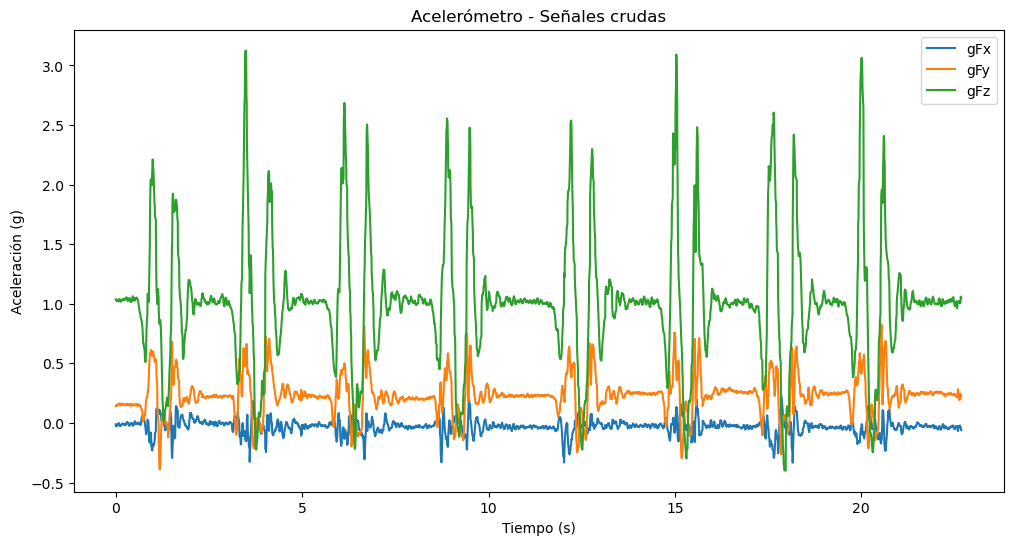

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df["time"], df["gFx"], label="gFx")
plt.plot(df["time"], df["gFy"], label="gFy")
plt.plot(df["time"], df["gFz"], label="gFz")
plt.legend()
plt.xlabel("Tiempo (s)")
plt.ylabel("Aceleración (g)")
plt.title("Acelerómetro - Señales crudas")
plt.show()


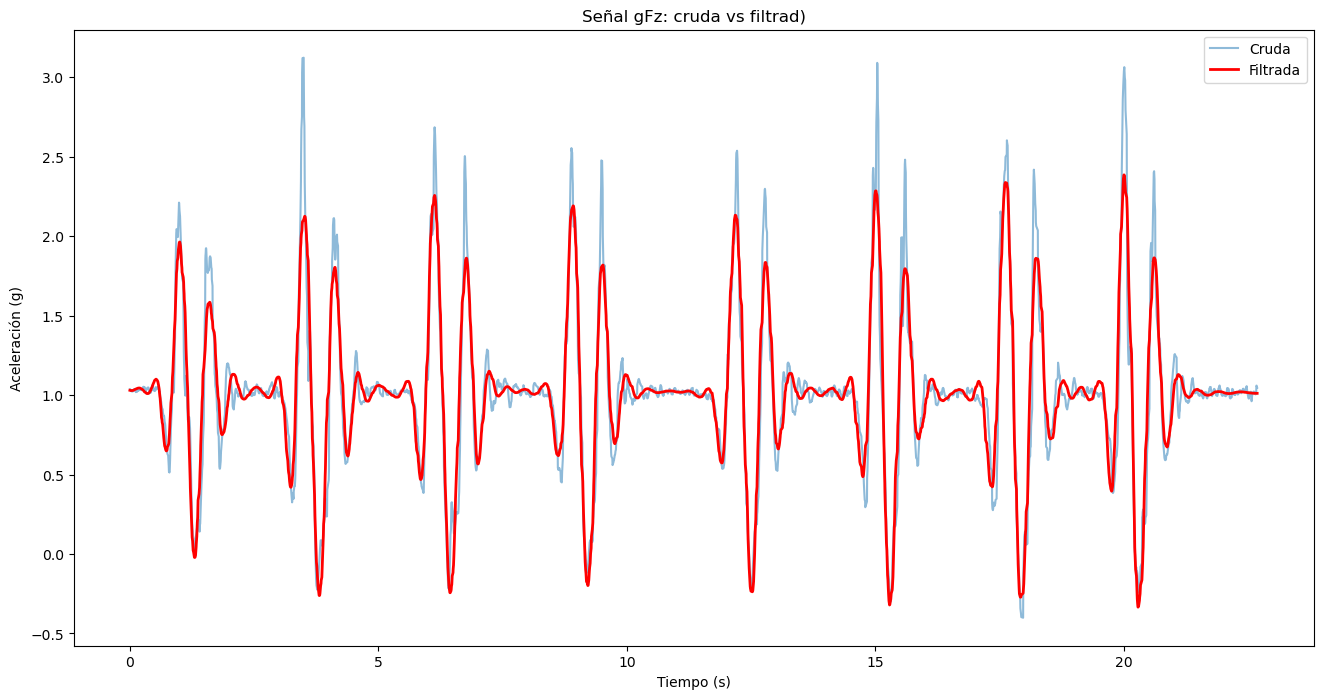

In [14]:
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

fs = 400
fc = 5   
w = fc / (fs/2)

b, a = butter(6, w, btype="low")
df["gFz_filt"] = filtfilt(b, a, df["gFz"])

plt.figure(figsize=(16,8))
plt.plot(df["time"], df["gFz"], alpha=0.5, label="Cruda")
plt.plot(df["time"], df["gFz_filt"], label="Filtrada", linewidth=2, color="red")
plt.xlabel("Tiempo (s)")
plt.ylabel("Aceleración (g)")
plt.title("Señal gFz: cruda vs filtrad)")
plt.legend()
plt.show()


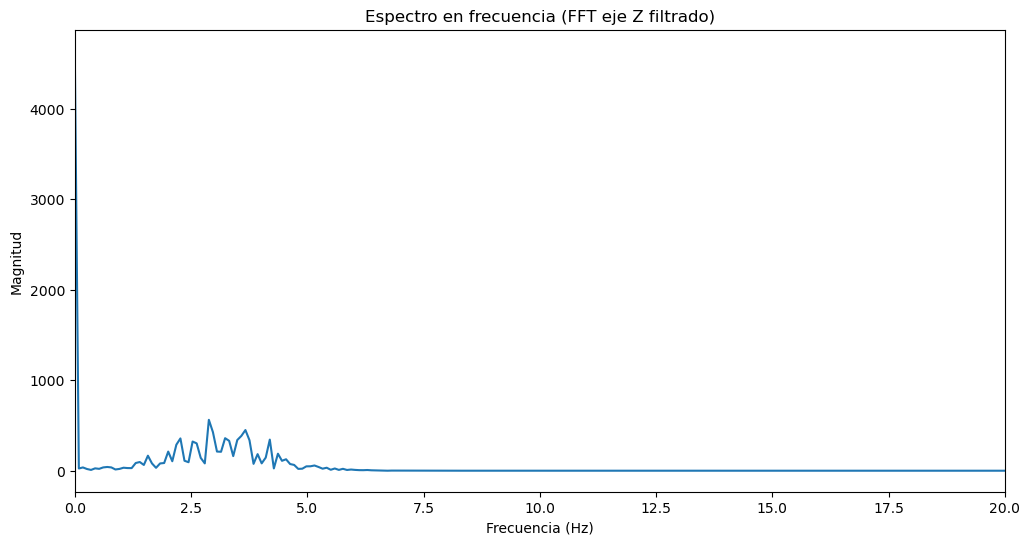

In [18]:
import numpy as np

N = len(df["gFz_filt"])
fft_vals = np.fft.rfft(df["gFz_filt"])
fft_freqs = np.fft.rfftfreq(N, d=1/fs)

plt.figure(figsize=(12,6))
plt.plot(fft_freqs, np.abs(fft_vals))
plt.xlim(0, 20)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.title("Espectro en frecuencia (FFT eje Z filtrado)")
plt.show()
